<a href="https://colab.research.google.com/github/radinelageorgieva/plant-disease-classification/blob/main/Plant_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 132.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [43]:
import mlflow
import torch
import os
from torchvision import datasets,  models, transforms
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Subset, WeightedRandomSampler, DataLoader
import copy
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

#Plant Disease Classification using EfficientNet-B0 Transfer learning and explainable AI with Grad-CAM

#Introduction

The primary objective of this project is automated Plant Disease Classification utilizing deep convolutional neural networks (CNNs). The dataset used is Plant Diseases dataset sourced from Kaggle/https://www.kaggle.com/datasets/saroz014/plant-diseases. It contains images of crop leaves categorized into 38 distinct classes: 23 classes representing various plant phytopathologies and 15 classes with healthy plant leaves. The dataset is structured into two main parts: Train folder containing approx. 173,000 images and a test folder containing approx. 43,000 images.
#Methodology Framework:

##1. MLflow Integration
MLOps framework - MLflow is integrated into the experimental setup. MLflow tracking server monitors training metrics in real time. This architecture allows for systematic logging of the loss and accuracy per epoch.

##2. Data preprocessing and Augmentation
Input image transformations were applied to standardize the data and artificially expand the dataset variety. This included resizing to 224 × 224 pixels, random horizontal/vertical flips, and tensor normalization based on ImageNet channel statistics.

##3. Exploratory data analysis (EDA)
This step includes generating a class distribution analysis and visual inspection grids to evaluate data quality, verify image characteristics, and map the exact sample distribution across all 38 categories.

##4. Dataset stratification
I split the training folder into two parts using a 90/10 ratio. I get train_data (90% for training) and val_data (10% for validation). I use stratified splitting, which means both parts keep the exact same percentages for all 38 diseases.


## 5. Class imbalance assessment and sampling strategy
Based on the outcomes of the EDA phase, the workflow integrates a conditional balancing strategy. If a significant class imbalance is detected, a **WeightedRandomSampler** will be configured. This sampler calculates a specific weight for each category based strictly on the 90% remaining training set so that rare classes receive a higher probability of being selected, while very common classes receive lower weights using the formula:

$$P_i = \frac{1}{\text{count}(\text{class}_i)}$$

This approach is planned to ensure that the model encounters an evenly distributed mix of plant pathologies during training, preventing the network from developing a bias toward majority classes.


##6. Transfer Learning and classifier design

For transfer learning I utilized EfficientNet-B0, a convolutional neural network pre-trained on more than one million images from the ImageNet database. Capable of classifying images into 1000 object categories the network learned rich feature representations across a wide range of images. EfficientNet-B0 requires an image input size of 224x224 pixels and the dataset was resized to these dimensions. EfficientNet has scaling method, which uniformly scales all dimensions of depth, width, and resolution, enable the model to achieve maximum accuracy gains efficiently.
All deep convolutional layers responsible for feature extraction were frozen. The default classifier head was replaced with a custom sequential architecture containing a **Dropout layer (p = 0.2) for regularization** and a **Linear layer** mapping the 1,280 extracted features to the 38 output classes.

##7. Model training and optimization

The model was optimized using the **Adam optimizer** with a **learning rate (lr = 0.0001)**. The optimization criterion is the **Cross-Entropy Loss**, which evaluates the model's performance by measuring the difference between the predicted probability distributions and the true labels:

$$ \text{Loss} = -\sum_{c=1}^{M} y_c \log(p_c) $$

Where $M = 38$ is the total number of plant disease classes. The variable $y_c$ acts as a binary indicator (it equals for the correct disease class, and 0 for all other 37 incorrect classes). The predicted probability $p_c$ for each class is calculated by applying the Softmax function to the model's raw outputs ($z_c$):

$$ p_c = \frac{e^{z_c}}{\sum_{j=1}^{M} e^{z_j}} $$


##8. Evaluation and visualization
* Learning curves (training and validation curves):
Generated dynamically using the **MLflowClient API** to plot Loss vs. Epochs and Accuracy vs. Epochs. These curves demonstrate model convergence and verify the absence of overfitting.
* Normalized confusion matrix: A 38 × 38 heatmap displaying accuracy percentages for each class.

##9. Failure modes analysis
Analysis of the images where the model made wrong predictions. I will plot a gallery of the top mistakes to see exactly why the model got confused.

## 10. Explainable AI (XAI) with Grad-CAM
Apply Gradient-weighted Class Activation Mapping (Grad-CAM) to validate the visual reliability of the network. This technique generates colorful heatmaps over the leaves to show exactly which pixel areas and lesions the model focuses on to make its final decision.

## 11. Final Model test
Evaluate the finalized weights of the trained model against the independent test dataset to obtain the definitive baseline accuracy of the computer vision workflow.

##Conclusion



##1. MLflow Integration

In [3]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
mlflow.set_tracking_uri("file:/content/drive/MyDrive/DeepLearning/ML plant diseases/mlflow_runs")

In [6]:
mlflow.set_experiment("Transfer_learning_plant_disease_classification")

<Experiment: artifact_location=('file:///content/drive/MyDrive/DeepLearning/ML plant '
 'diseases/mlflow_runs/515034867812171804'), creation_time=1782977085987, effective_trace_archival_retention=None, experiment_id='515034867812171804', last_update_time=1782977085987, lifecycle_stage='active', name='Transfer_learning_plant_disease_classification', tags={}, trace_location=None, workspace='default'>

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Data preprocessing and Augmentation

### Dataset loading

In [8]:
!ls "/content/drive/My Drive/DeepLearning/ML plant diseases"

dataset_itr2.zip  mlflow_runs			train_1
dvc-storage	  Plant-Disease-Classification	Untitled0.ipynb


In [9]:
!unzip -q "/content/drive/My Drive/DeepLearning/ML plant diseases/dataset_itr2.zip" -d /content/

In [10]:
!ls /content/

drive  sample_data  test  train


In [11]:
train_dir = '/content/train'
test_dir = '/content/test'

I applied several input image transformations to the training data in order to artificially expand the dataset variety and to prevent overfitting. This includes random cropping and resizing, and random horizontal flips.
The **ToTensor()** function is utilized to convert the raw images into PyTorch tensors. Additionally, for data standardization, I configured the normalization layer using the standard ImageNet channel statistics. The images were normalized with a specific mean of [0.485, 0.456, 0.406] and a standard deviation of [0.229, 0.224, 0.225]. The mathematical formula is:
$$\text{image}=\frac{\text{image}-\text{mean}}{\text{std}}$$
This scaling improves and speeds up neural network training because the input data is centered around a zero value and shares the similar distribution. Also, this scaling matches the exact pixel domain that the pre-trained EfficientNet backbone expects, accelerating model training and convergence.

In [12]:
#data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [13]:
#loading datasets
full_train_dataset = datasets.ImageFolder(train_dir, transform = data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform = data_transforms['test'])

##3. Exploratory data analysis

In [14]:
class_names = full_train_dataset.classes

In [15]:
class_counts = np.bincount(full_train_dataset.targets)

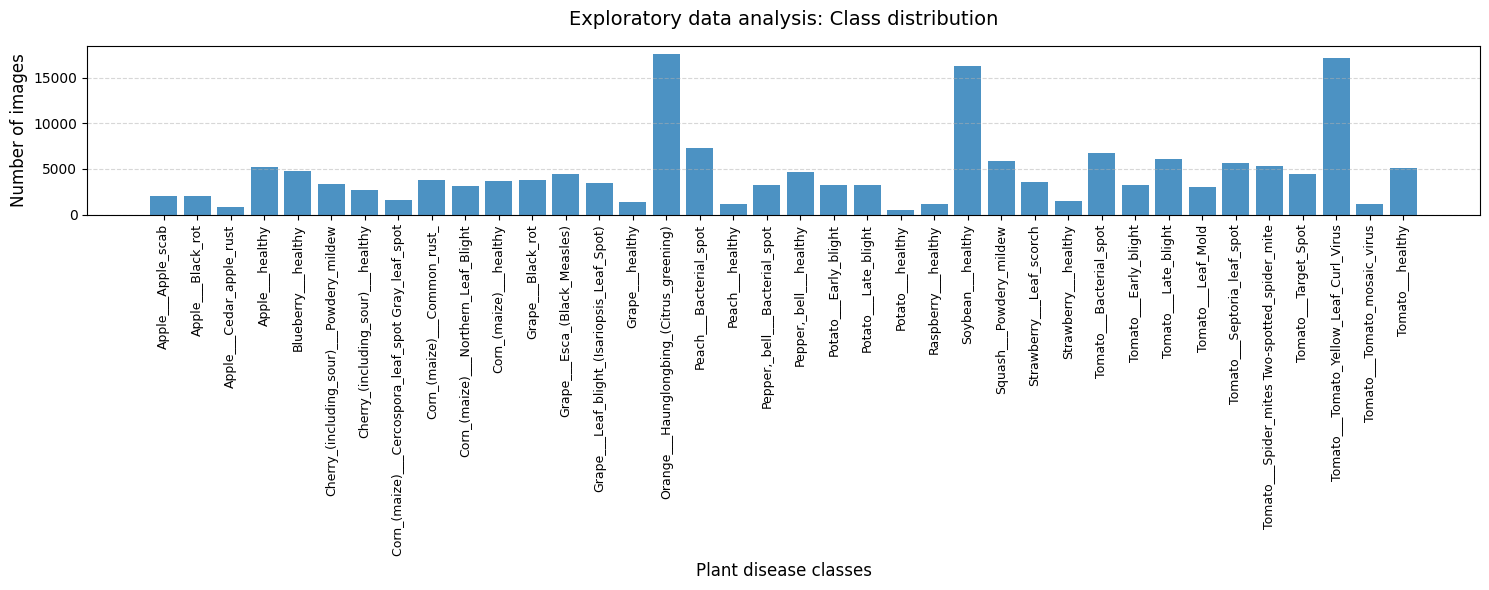

In [16]:
plt.figure(figsize = (15, 6))
plt.bar(class_names, class_counts, alpha = 0.8)
plt.title('Exploratory data analysis: Class distribution', fontsize = 14, pad = 15)
plt.xlabel('Plant disease classes', fontsize = 12)
plt.ylabel('Number of images', fontsize = 12)
plt.xticks(rotation = 90, fontsize = 9)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

The analysis chart reveals a significant class imbalance across the 38 plant categories. The image distribution is highly unbalanced, with some rare diseases containing only 400-500 samples, while dominant categories exceed 17,000 images. Model trainig on such skewed data would cause a severe bias toward the majority classes, leading to low accuracy on rare diseases. To mitigate this issue, I will implement **WeightedRandomSampler** in the training phase. This sampler calculates a specific weight for each category so that rare classes receive a higher probability of being selected, while very common classes receive lower weights, forcing the model to learn from all plant diseases equally.

In [17]:
#Dataset analysis: class distribution
class_counts = {folder: len(os.listdir(os.path.join(train_dir, folder))) for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))}

In [18]:
for class_name, count in sorted(class_counts.items(), key = lambda x: x[1], reverse = True):
    print(f"Class: {class_name:<30} | Count images: {count}")

Class: Orange___Haunglongbing_(Citrus_greening) | Count images: 17624
Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus | Count images: 17144
Class: Soybean___healthy              | Count images: 16288
Class: Peach___Bacterial_spot         | Count images: 7352
Class: Tomato___Bacterial_spot        | Count images: 6808
Class: Tomato___Late_blight           | Count images: 6109
Class: Squash___Powdery_mildew        | Count images: 5872
Class: Tomato___Septoria_leaf_spot    | Count images: 5668
Class: Tomato___Spider_mites Two-spotted_spider_mite | Count images: 5364
Class: Apple___healthy                | Count images: 5264
Class: Tomato___healthy               | Count images: 5089
Class: Blueberry___healthy            | Count images: 4808
Class: Pepper,_bell___healthy         | Count images: 4725
Class: Tomato___Target_Spot           | Count images: 4496
Class: Grape___Esca_(Black_Measles)   | Count images: 4428
Class: Corn_(maize)___Common_rust_    | Count images: 3816
Class: Grape___Black

### Random images

In [19]:
random_indices = random.sample(range(len(full_train_dataset)), 8)

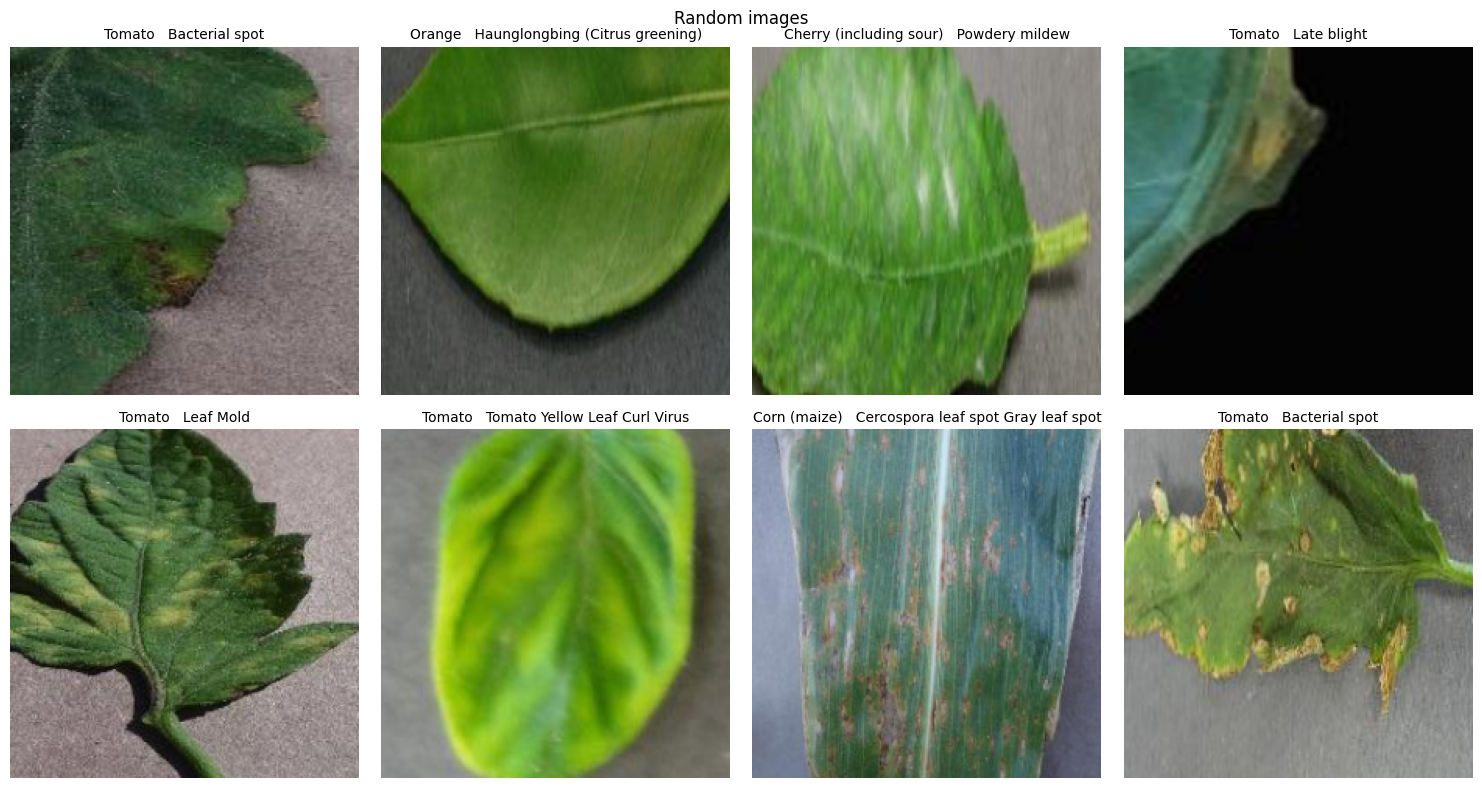

In [20]:
plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
  image, label = full_train_dataset[idx]
  class_name = full_train_dataset.classes[label]

  #invert ImageNet normalization to restore original pixel range
  img = image.permute(1, 2, 0).numpy()
  img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

  plt.subplot(2, 4, i + 1)
  plt.imshow(img)

  if '___' in class_names:
    parts = class_name.split('___')
    plant = parts[0].replace('_', ' ')
    condition = parts[1].replace('_', ' ')
    display_title = f"{plant}\n({condition})"
  else:
        display_title = class_name.replace('_', ' ')
  plt.title(display_title, fontsize = 10)
  plt.axis('off')

plt.suptitle("Random images")
plt.tight_layout(h_pad=3.0)
plt.show()

##4. Data stratification

In [21]:
all_train_indices = list(range(len(full_train_dataset)))
all_train_labels = torch.tensor(full_train_dataset.targets)

**all_train_indices** creates a simple list of numbers from 0 to 217,000. Each photo gets its own number. This saves computer memory (RAM).\
**all_train_labels** convert the list of folder/class indices into a PyTorch tensor for stratification math

In [22]:
#stratification - 0.9 for train_indices and 0.1 for val_indices
train_indices = []
val_indices = []

#stratification
for class_idx in torch.unique(all_train_labels):
  class_indices = (all_train_labels == class_idx).nonzero(as_tuple = True)[0] #get the images with True

  #random shuffling
  perm = torch.randperm(len(class_indices), generator = torch.Generator().manual_seed(42))
  class_indices = class_indices[perm]

  #get 10% for val set
  val_size = int(len(class_indices) * 0.1)
  val_indices.extend(class_indices[:val_size].tolist())
  train_indices.extend(class_indices[val_size:].tolist())


First I create two empty lists, train_indices and val_indices, to act as containers for storing the final image numbers. I use a for loop to enter each of the 38 categories one by one. This step guarantees the stratification process. Inside the loop, I find the exact location of all images belonging to the current category. Then, I shuffle these data randomly using torch.randperm. I also use a fix manual_seed to lock the randomness so the results are always reproducible. Finally, I extract 10% of the shuffled data per category and moved them to val_indices. The remaining 90% went to train_indices.

In [23]:
#create virtual subsets based on stratified indices to split data without duplicating images in RAM
train_data = Subset(full_train_dataset, train_indices)
val_data = Subset(full_train_dataset, val_indices)

This approach creates virtual datasets that simply wrap around the original data using the calculated stratified indices. Images are only read from the disk when the model requests them during training or validation, which makes this process memory-efficient.

In [24]:
val_data.dataset = copy.deepcopy(full_train_dataset)

In [25]:
val_data.dataset.transform = data_transforms['test']

Validation data needs raw, not augmented data. Therefore I create a deep copy of the original dataset structure for val_data and apply the same clean transformations as the test set, only resizing and cropping, without any random flips.

In [26]:
len(train_data), len(val_data)

(156445, 17363)

In [27]:
image, label = train_data[50]

In [28]:
image.shape, label

(torch.Size([3, 224, 224]), 0)

In [29]:
train_data.indices[:10]

[1910, 1500, 699, 483, 673, 1181, 1045, 1917, 1862, 636]

In [30]:
val_data.indices[:10]

[582, 633, 564, 490, 1202, 1986, 496, 75, 1262, 569]

##5. Class imbalance assessment and sampling strategy

Here I apply WeightedRandomSampler to fix the problem with unbalanced data. First, I extract the labels for the training subset to compute the exact class frequencies.

In [31]:
train_targets = [all_train_labels[i] for i in train_indices]

 Then I calculate the class weights using the inverse class frequency method. This creates a specific weight for every individual sample, ensuring that rare categories have a higher probability of being selected during training, while common categories are heavily down-weighted.

In [32]:
counts_array = np.bincount(train_targets)

In [33]:
class_weights = 1 / counts_array

In [34]:
sample_weights = [class_weights[t] for t in train_targets]

In [35]:
sampler = WeightedRandomSampler(weights = sample_weights, num_samples = len(sample_weights), replacement=True)

WeightedRandomSampler with replacement = True use the calculated weights to change the selection probability for each image. This allows PyTorch to select rare images multiple times and common images less often, creating a balanced stream of data for the model while keeping the total training size the same.

In [36]:
batch_size = 32

In [37]:
train_loader = DataLoader(train_data, batch_size = batch_size, sampler = sampler)
val_loader = DataLoader(val_data, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

The DataLoader loads the image pixels and labels in small batches of 32.  This process saves RAM memory because the computer reads only 32 images at a time. The train_loader uses sampler to ensure every batch is balanced, while val_loader and test_loader keep shuffle = False to evaluate the model on the clean, sequential data.

##6. Transfer Learning and classifier design

I load the EfficientNet-B0 model with its default pre-trained weights (EfficientNet_B0_Weights.DEFAULT). To use the features that the network already knows and stop them from changing, I froze all the base weights by setting requires_grad = False. Then I adopt the original classifier for my dataset. I take the number of input features from the last layer and replace the default classifier with a custom nn.Sequential block. Inside I put a Dropout layer with a 0.2 probability to prevent overfitting, followed by a Linear layer to map the features to my specific number of classes. Then I move the model to the computing device.

In [38]:
#load efficientnetB0
model = efficientnet_b0(weights = EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


In [39]:
#freeze the base weights
for param in model.parameters():
    param.requires_grad = False

In [40]:
in_features = model.classifier[1].in_features

In [41]:
num_classes = len(train_data.dataset.classes)

In [44]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features, num_classes)
)

In [45]:
model = model.to(device)